<a href="https://colab.research.google.com/github/smcgovern-proj/neuromatch_ecog_project/blob/main/broadband_mean_electrode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# broadband_mean_electrode

This notebook processes electrophysiological (ECoG) data from a stimulus-presentation experiment (specifically the "Faces vs. Houses" dataset). It extracts high-frequency broadband (gamma) amplitude envelopes, segments them into trial epochs, and computes time-resolved statistics (mean and variance).

---

### Pipeline Configuration

The pipeline uses the following default parameters, designed in accordance with Kai Miller's broadband spectral analysis methods:

* **Sampling Rate ($f_s$):** $1000\text{ Hz}$

* **Frequency Band:** $[70, 150]\text{ Hz}$ (Broadband high-gamma range)


* **Epoch Window:** $-199\text{ ms}$ to $+400\text{ ms}$ relative to stimulus onset ($t_{\text{on}}$)



---

### Core Functions

#### 1. `get_epoch`

Segments the continuous voltage timeseries into discrete trial windows.

* **Inputs:**
* `V`: Raw voltage array of shape `(samples, electrodes)`.


* `t_on`: Stimulus onset timestamps.


* `start_offset` / `end_offset`: Temporal window bounds.




* **Returns:** A 3D numpy array of shape `(n_epochs, epoch_length, n_electrodes)`.



#### 2. `get_envelope`

Extracts the instantaneous amplitude envelope of the signal.

* **Methodology:** Applies a 3rd-order Butterworth bandpass filter ($70\text{--}150\text{ Hz}$) and computes the analytical signal's magnitude using the Hilbert transform.


* **Returns:** Amplitude envelope with the same shape as the input voltage matrix.



#### 3. `extract_envelope_bins`

Slices the calculated trial envelopes into overlapping temporal windows and extracts features.

* **Default Parameters:** Window length of $60$ samples ($60\text{ ms}$) and step size of $40$ samples ($40\text{ ms}$).


* **Metrics Calculated:** Mean amplitude and variance per time bin.


* **Returns:** A nested dictionary containing structured trial, electrode, and window metrics.



#### 4. `results_to_array`

Converts the nested results dictionary back into structured, flat numpy arrays for downstream machine learning or statistical analysis.

* **Returns:** `means` and `variances`, both of shape `(n_epochs, n_windows, n_electrodes)`.

### To-do
1. Separate between faces and houses
2. Need to check if oscillations are true


In [64]:
# @title Configure

# Window preset per Kai Miller's paper
start_offset = -199
end_offset = 400

# Window
win_length=60
step=40

# Filtering
bandpass = [70, 150] #will need to check if oscillations are true
fs = 1000

# Desired subjects
electrode_dict = {
    '0': [11, 35],
    '1': [43, 46],
    '2': [35, 7],
    '3': [15, 17],
    '4': [23, 24],
    '5': [25, 27],
    '6': False
}

In [1]:
# @title Data retrieval
import os, requests

fname = 'faceshouses.npz'
url = "https://osf.io/argh7/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [43]:
# @title Imports and plot settings

from matplotlib import rcParams
from matplotlib import pyplot as plt
from scipy import signal
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 15
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

In [3]:
# @title Data loading
import numpy as np

alldat = np.load(fname, allow_pickle=True)['dat']

In [5]:
# @title Epoch segmentation
def get_epoch(V, t_on, start_offset, end_offset):
  # Epoch
  epochs_list = []

  for on_time in t_on:
      start = on_time + start_offset
      end = on_time + end_offset

      # Window
      trial_window = V[start:end]
      epochs_list.append(trial_window)

  # Convert no np.array
  epochs = np.array(epochs_list)

  return epochs

In [16]:
# @title Characteristic extraction

def get_envelope(V):
  '''
  Get envelope for voltage using bandpass filter and Hilbert transform

  Args:
    V: float32 np.array (samples, electrodes)

  Return:
    env: amplitude envelope, same shape as V
  '''
  # Design bandpass filter
  b, a = signal.butter(3, bandpass, btype='bandpass', fs=fs)

  # Filter each electrode separately (axis=0 is time/samples)
  filtered_V = signal.filtfilt(b, a, V, axis=0)

  # Get envelope via Hilbert transform
  env = np.abs(signal.hilbert(filtered_V, axis=0))

  return env

def get_power(V):
  '''
  Get broadband power for voltage

  Args:
    V: float32 np.array (samples, electrodes)

  Return:
    power: power same range as V
  '''

  b, a = signal.butter(3, [50], btype='high', fs=1000)
  V = signal.filtfilt(b, a, V, 0)

  V = np.abs(V)**2

  b, a = signal.butter(3, [10], btype='low', fs=1000)
  V = signal.filtfilt(b, a, V, 0)

  V = V/V.mean(0)

  return V


In [28]:
# @title Time bin segmentation

def extract_envelope_bins(epochs, win_length, step):
  '''
  Break epochs into overlapping time bins and compute envelope statistics.

  Args:
    epochs: np.array (n_epochs, samples, electrodes)
    win_length: window length in samples
    step: window step in samples (overlap = win_length - step)

  Return:
    results: dict with structure:
      results['trial'][trial_idx]['electrode'][elec_idx] = {
        'mean': np.array (n_windows,),
        'variance': np.array (n_windows,)
      }
  '''

  n_epochs, epoch_length, n_electrodes = epochs.shape

  # Calculate number of windows
  n_windows = int(np.floor((epoch_length - win_length) / step)) + 1

  # Initialize results structure
  results = {
    'trial': [
      {'electrode': [{} for _ in range(n_electrodes)]}
      for _ in range(n_epochs)
    ],
    'metadata': {
      'n_epochs': n_epochs,
      'n_windows': n_windows,
      'n_electrodes': n_electrodes,
      'win_length': win_length,
      'step': step
    }
  }

  # Process each trial
  for trial_idx, epoch in enumerate(epochs):
    # epoch shape: (samples, electrodes)

    # Calculate envelope for entire trial
    envelope = get_power(epoch)  # Shape: (samples, electrodes)

    # Process each electrode
    for elec_idx in range(n_electrodes):
      envelope_signal = envelope[:, elec_idx]  # Shape: (samples,)

      mean_amplitudes = []
      variances = []

      # Extract time bins with overlap
      for i in range(n_windows):
        start = i * step
        end = start + win_length

        # Get envelope in this time bin
        bin_envelope = envelope_signal[start:end]

        # Calculate mean amplitude and variance
        mean_amp = np.mean(bin_envelope)
        var = np.var(bin_envelope)

        mean_amplitudes.append(mean_amp)
        variances.append(var)

      # Store results for this electrode
      results['trial'][trial_idx]['electrode'][elec_idx] = {
        'mean': np.array(mean_amplitudes),
        'variance': np.array(variances)
      }

  return results


def results_to_array(results):
  '''
  Convert structured results dict to numpy arrays for easier analysis.

  Return:
    means: np.array (n_epochs, n_windows, n_electrodes)
    variances: np.array (n_epochs, n_windows, n_electrodes)
  '''
  n_epochs = results['metadata']['n_epochs']
  n_windows = results['metadata']['n_windows']
  n_electrodes = results['metadata']['n_electrodes']

  means = np.zeros((n_epochs, n_windows, n_electrodes))
  variances = np.zeros((n_epochs, n_windows, n_electrodes))

  for trial_idx in range(n_epochs):
    for elec_idx in range(n_electrodes):
      means[trial_idx, :, elec_idx] = results['trial'][trial_idx]['electrode'][elec_idx]['mean']
      variances[trial_idx, :, elec_idx] = results['trial'][trial_idx]['electrode'][elec_idx]['variance']

  return means, variances

In [80]:
clean_data_sub = {}

for idx, subject in enumerate(alldat):
    if not electrode_dict.get(str(idx), False):
        continue

    dat = subject[0]

    V = dat['V'].astype('float32')
    epochs = get_epoch(V, dat['t_on'], start_offset, end_offset)
    results = extract_envelope_bins(epochs, win_length, step)
    means, variances = results_to_array(results)

    # Select electrodes and build features
    sel = electrode_dict[str(idx)]
    means = means[:, :, sel]                 # (n_epochs, n_bins, n_sel_electrodes)
    X = means.reshape(means.shape[0], -1)  # (n_epochs, n_features)

    # Build labels
    stim = np.asarray(dat['stim_id'])
    labels = np.where(stim <= 50, 'house', 'face')

    clean_data_sub[idx] = {"X": X, "labels": labels}
    print(f'Done: {idx}')

Done: 0
Done: 1
Done: 2
Done: 3
Done: 4
Done: 5


In [81]:
for idx, sub_data in clean_data_sub.items():
    X_sub = sub_data["X"]
    y_sub = sub_data["labels"]

    # Fit on the sub's data and evaluate on the same data (training accuracy)
    log_reg.fit(X_sub, y_sub)
    labels_pred = log_reg.predict(X_sub)

    acc = accuracy_score(y_sub, labels_pred)
    sub_data["train_accuracy"] = acc

    # 10-fold CV accuracy scores on the sub's data
    cv_scores = cross_val_score(
        LogisticRegression(max_iter=5000),
        X_sub, y_sub,
        cv=10
    )
    sub_data["accuracies"] = cv_scores  # array of length 10
    sub_data["cv_mean_accuracy"] = cv_scores.mean()
    sub_data["cv_std_accuracy"] = cv_scores.std()

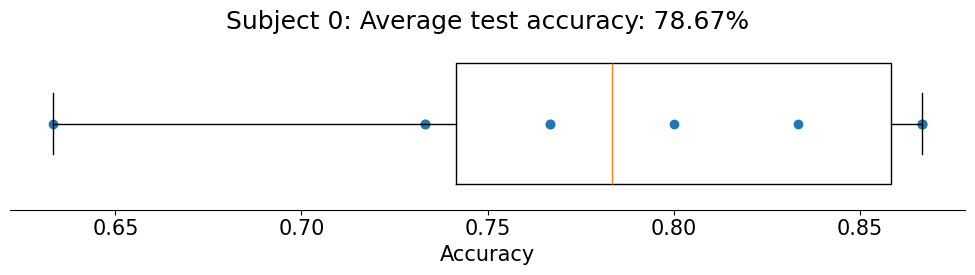

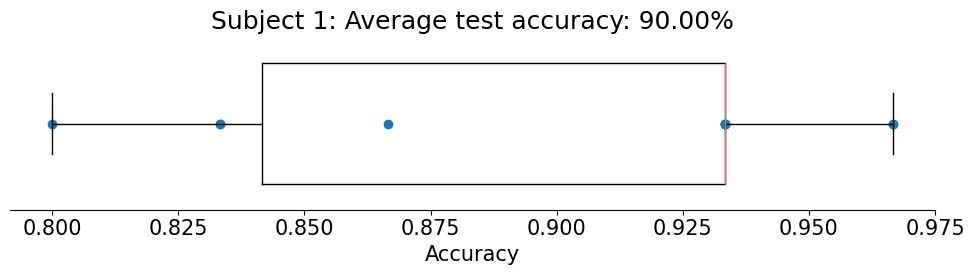

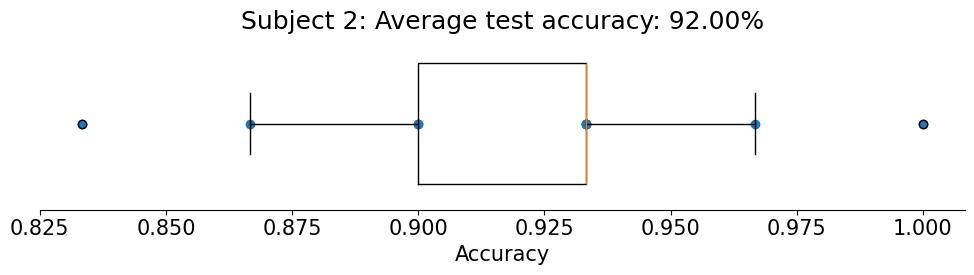

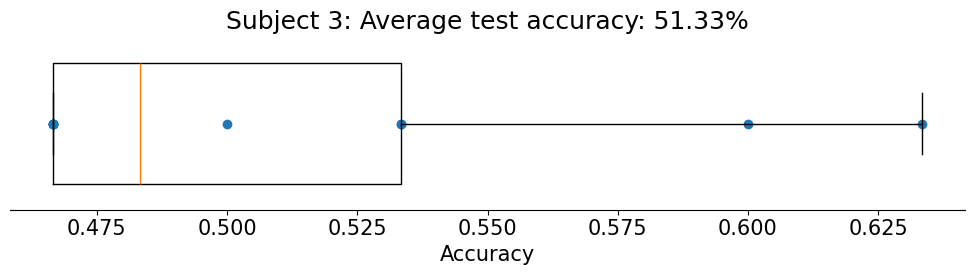

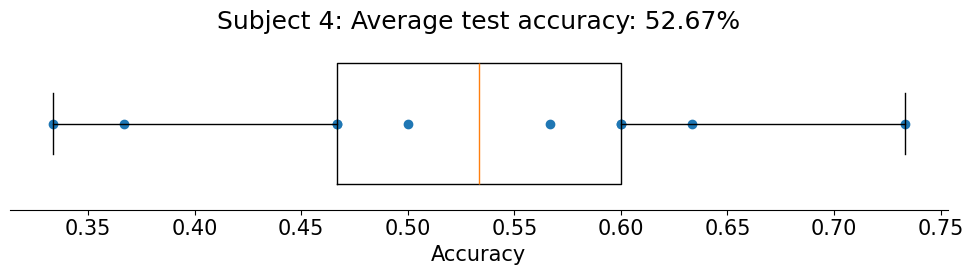

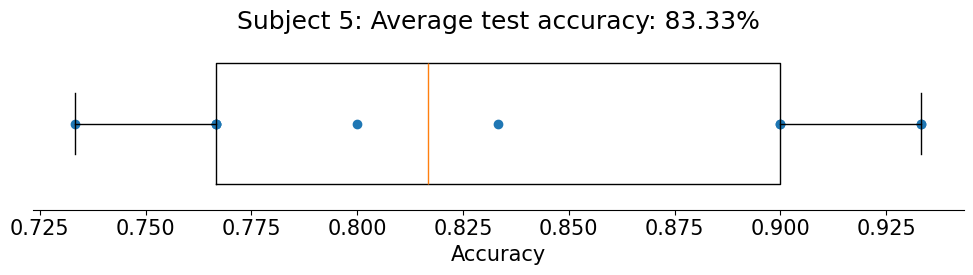

In [82]:
# @title Acc plot

for idx, sub_data in data_by_sub.items():
    accuracies = sub_data["accuracies"]
    y_sub = sub_data["labels"]

    f, ax = plt.subplots(figsize=(len(accuracies), 3))
    ax.boxplot(accuracies, vert=False, widths=.7)
    ax.scatter(accuracies, np.ones(len(accuracies)))
    ax.set(
      xlabel="Accuracy",
      yticks=[],
      title=f"Subject {idx}: Average test accuracy: {accuracies.mean():.2%}"
    )
    ax.spines["left"].set_visible(False)
    plt.show()